In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron as SklearnPerceptron

In [56]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=10, hypercube=False, random_state=41)

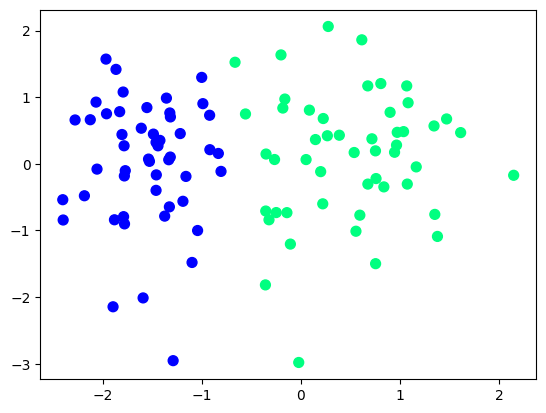

In [57]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.show()

In [62]:
class perceptron:
  def __init__(self, epochs = 1000, lr = 0.1):
    self.lr = lr
    self.epochs = epochs

  def skl_perceptron(self,X,y):
    sk_perceptron = SklearnPerceptron(random_state=42)
    sk_perceptron.fit(X, y)

    sk_coef = sk_perceptron.coef_[0]
    sk_intercept = sk_perceptron.intercept_[0]

    m_sk = -(sk_coef[0] / sk_coef[1])
    b_sk = -(sk_intercept / sk_coef[1])

    X_input_sk = np.linspace(-3, 3, 100)
    y_input_sk = m_sk * X_input_sk + b_sk
    return X_input_sk, y_input_sk

  def step_perceptron(self,X,y):
    X_biased = np.insert(X, 0 , 1, axis = 1)
    W = np.ones(X_biased.shape[1])
    lr = self.lr
    epochs = self.epochs

    for i in range(epochs):
      s = np.random.randint(0, len(X_biased))
      y_hat = self.step(np.dot(X_biased[s], W))
      W = W + lr * (y[s] - y_hat) * X_biased[s]
    return W[0], W[1:]

  def sigmoid_perceptron(self, X, y):
    X_biased = np.insert(X, 0 , 1, axis = 1)
    W = np.ones(X_biased.shape[1])
    lr = self.lr
    epochs = self.epochs
    n_samples = X_biased.shape[0]
    bias = 1

    for i in range(epochs):
      y_hat = self.sigmoid(np.dot(X_biased, W) + bias)

      dw = np.dot(X_biased.T, (y_hat - y)) / n_samples
      db = np.sum(y_hat - y) / n_samples

      W = W - lr * dw
      bias = bias - lr * db
    return W, bias

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def step(self, z):
    return 1 if z > 0 else 0

  def run_all_perceptrons(self, X, y):
    # Sklearn Perceptron
    X_input_sk, y_input_sk = self.skl_perceptron(X, y)

    # Step Perceptron
    bias_step, weights_step = self.step_perceptron(X, y)
    m_step = -(weights_step[0] / weights_step[1])
    b_step = -(bias_step / weights_step[1])
    X_input_step = np.linspace(-3, 3, 100)
    y_input_step = m_step * X_input_step + b_step

    # Sigmoid Perceptron
    W_sigmoid, bias_sigmoid = self.sigmoid_perceptron(X, y)
    m_sigmoid = -(W_sigmoid[1] / W_sigmoid[2])
    b_sigmoid = -((W_sigmoid[0] + bias_sigmoid ) / W_sigmoid[2])
    X_input_sigmoid = np.linspace(-3, 3, 100)
    y_input_sigmoid = m_sigmoid * X_input_sigmoid + b_sigmoid

    # Plotting all three
    plt.figure(figsize=(12, 8))
    plt.plot(X_input_sk, y_input_sk, color='green', linestyle='-', label='Sklearn Perceptron BFL')
    plt.plot(X_input_step, y_input_step, color='red', linestyle='--', label='Step Perceptron BFL')
    plt.plot(X_input_sigmoid, y_input_sigmoid, color='blue', linestyle=':', label='Sigmoid Perceptron BFL')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=50, alpha=0.8)
    plt.ylim(-3, 2)
    plt.title('Best Fit Line for Different Perceptron Implementations')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


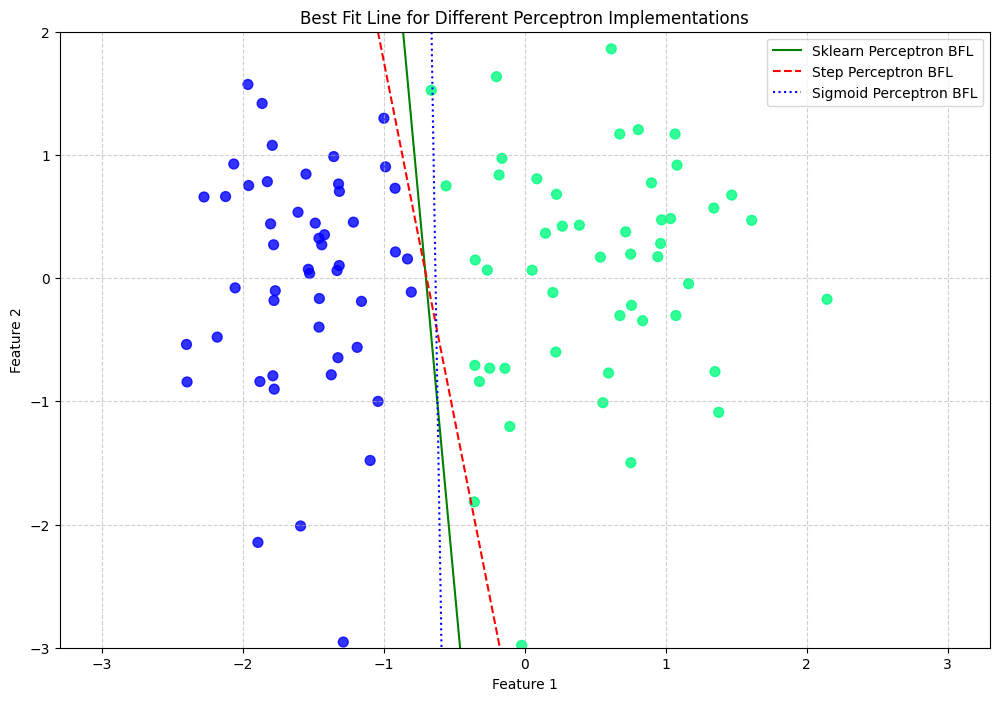

In [63]:
Perc = perceptron()
Perc.run_all_perceptrons(X, y)